Trento
(166, 600)
Training size and testing size of HSI are: torch.Size([94, 63, 7, 7]) and torch.Size([30214, 63, 7, 7])
Training size and testing size of LiDAR are: torch.Size([94, 1, 7, 7]) and torch.Size([30214, 1, 7, 7])


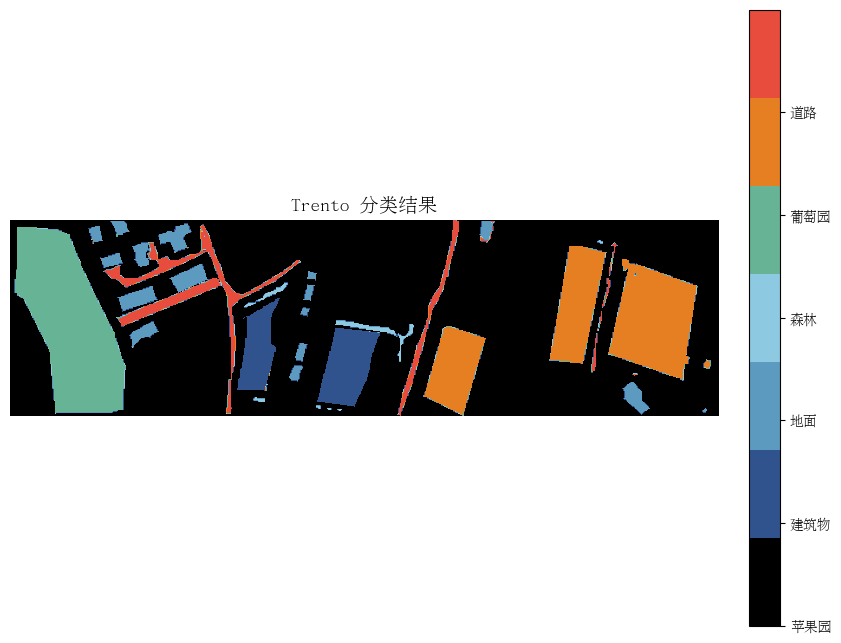

Saved to ./Trento/Trento_predicted_labels.png


In [6]:
import argparse
import os
from matplotlib import font_manager
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import dataset
from utils import set_seed

# ====================== 字体设置（支持中文） ======================
font_path = "/usr/share/fonts/truetype/arphic/uming.ttc"
font_prop = font_manager.FontProperties(fname=font_path)
matplotlib.rcParams['axes.unicode_minus'] = False

# ====================== 参数 ======================
parse = argparse.ArgumentParser()
parse.add_argument('--dataset', default='Muufl',
                   choices=['Houston', 'Trento', 'Muufl'])
parse.add_argument('--seed', default=42)
parse.add_argument('--train_num', default=0.003)
parse.add_argument('--batchsize', default=64)
parse.add_argument('--test_batchsize', default=5000)
parse.add_argument('--patchsize', default=11)
parse.add_argument('--channels', default=12)
args = parse.parse_args(args=[])

set_seed(args.seed)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

# ====================== 加载数据 ======================
[data_HSI, data_LiDAR, gt, class_count, dataset_name] = dataset.get_dataset(args.dataset)
height, width, bands = data_HSI.shape

data_LiDAR = data_LiDAR[:, :, 0]
[data_HSI, data_LiDAR] = dataset.data_standard(data_HSI, data_LiDAR)

# ====================== 划分数据 ======================
[train_label, test_label, _] = dataset.data_partition(
    class_count, gt, args.train_num
)

# ====================== Patch 构建 ======================
TestPatch_HSI, TestPatch_LiDAR = dataset.gen_cnn_data(
    data_HSI, data_LiDAR, args.patchsize,
    train_label, test_label, device
)

train_flat = train_label.reshape(-1)
test_flat = test_label.reshape(-1)

train_index = np.where(train_flat != 0)[0]
test_index = np.where(test_flat != 0)[0]

test_index_in_patch = np.arange(
    len(train_index),
    len(train_index) + len(test_index)
)

# ====================== 加载模型 ======================
model_path = f'./colorMap/{args.dataset}_best_model_89.9700.pt'
net = torch.load(model_path)
net.eval()
device = next(net.parameters()).device

# ====================== 推理 ======================
test_data = TensorDataset(
    TestPatch_HSI[test_index_in_patch],
    TestPatch_LiDAR[test_index_in_patch]
)
test_loader = DataLoader(
    test_data, batch_size=args.test_batchsize,
    shuffle=False, drop_last=False
)

pred_list = []
with torch.no_grad():
    for HSI, LiDAR in test_loader:
        logits, _ , _= net(HSI.to(device), LiDAR.to(device))
        pred_list.append(torch.argmax(logits, dim=1).cpu())

pred_test = torch.cat(pred_list).numpy()

# ====================== 回填整图（仅测试集） ======================
pred_map = np.zeros(height * width, dtype=np.int32)
pred_map[test_index] = pred_test + 1
pred_map = pred_map.reshape(height, width)

# ====================== 颜色 & 标签 ======================
if args.dataset == 'Houston':
    colors = np.array([
        [0, 0, 205], [0, 77, 255], [0, 145, 255], [0, 212, 255],
        [41, 255, 206], [96, 255, 151], [151, 255, 96],
        [206, 255, 41], [255, 230, 0], [255, 167, 0],
        [255, 104, 0], [255, 41, 0], [205, 0, 0], [128, 0, 0]
    ]) / 255.0

    class_names = [
        '健康草地', '受压草地', '人造草地', '树木', '土壤', '水体',
        '住宅区', '商业区', '道路', '高速公路',
        '铁路', '停车场1', '停车场2', '跑道'
    ]

elif args.dataset == 'Trento':
    colors = np.array([
    [49,  83,  141],   # 深冷蓝
    [92,  155, 191],   # 钢蓝
    [141, 201, 224],   # 浅冰蓝
    [102, 180, 149],   # 青绿色
    [230, 126, 34],    # 对比橙（暖色锚点）
    [231, 76,  60]     # 对比红（暖色锚点）
]) / 255.0

    class_names = ['苹果园', '建筑物', '地面', '森林', '葡萄园', '道路']

elif args.dataset == 'Muufl':
    colors = np.array([
        [70, 130, 180], [135, 206, 235], [176, 224, 230],
        [210, 180, 140], [205, 133, 63], [0, 191, 255],
        [112, 128, 144], [119, 136, 153], [169, 169, 169],
        [218, 168, 32], [175, 234, 212]
    ]) / 255.0

    class_names = [
        '树木', '纯草地', '地面草地', '土壤与沙地', '道路材料', '水体',
        '建筑物', '建筑阴影', '人行道', '黄色路缘', '布面板'
    ]

# 背景白色（不加标签）
colors = np.vstack([[1, 1, 1], colors])
cmap = ListedColormap(colors)

# ====================== 绘制（仅图像，不要标题/不加类别/不加坐标轴） ======================
plt.figure(figsize=(10, 8))
plt.imshow(pred_map, cmap=cmap, vmin=0, vmax=len(class_names))
plt.axis('off')  # 关闭坐标轴

# ====================== 保存 ======================
out_dir = f'./{args.dataset}'
os.makedirs(out_dir, exist_ok=True)
out_path = f'{out_dir}/{args.dataset}_SASS.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

print(f"Saved to {out_path}")



Bad key axes3d.automargin in file /home/cgw/anaconda3/envs/multi310/lib/python3.10/site-packages/matplotlib/mpl-data/matplotlibrc, line 430 ('axes3d.automargin: False  # automatically add margin when manually setting 3D axis limits')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.8.2/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution

Bad key image.interpolation_stage in file /home/cgw/anaconda3/envs/multi310/lib/python3.10/site-packages/matplotlib/mpl-data/matplotlibrc, line 606 ('image.interpolation_stage: data     # see help(imshow) for options')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.8.2/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


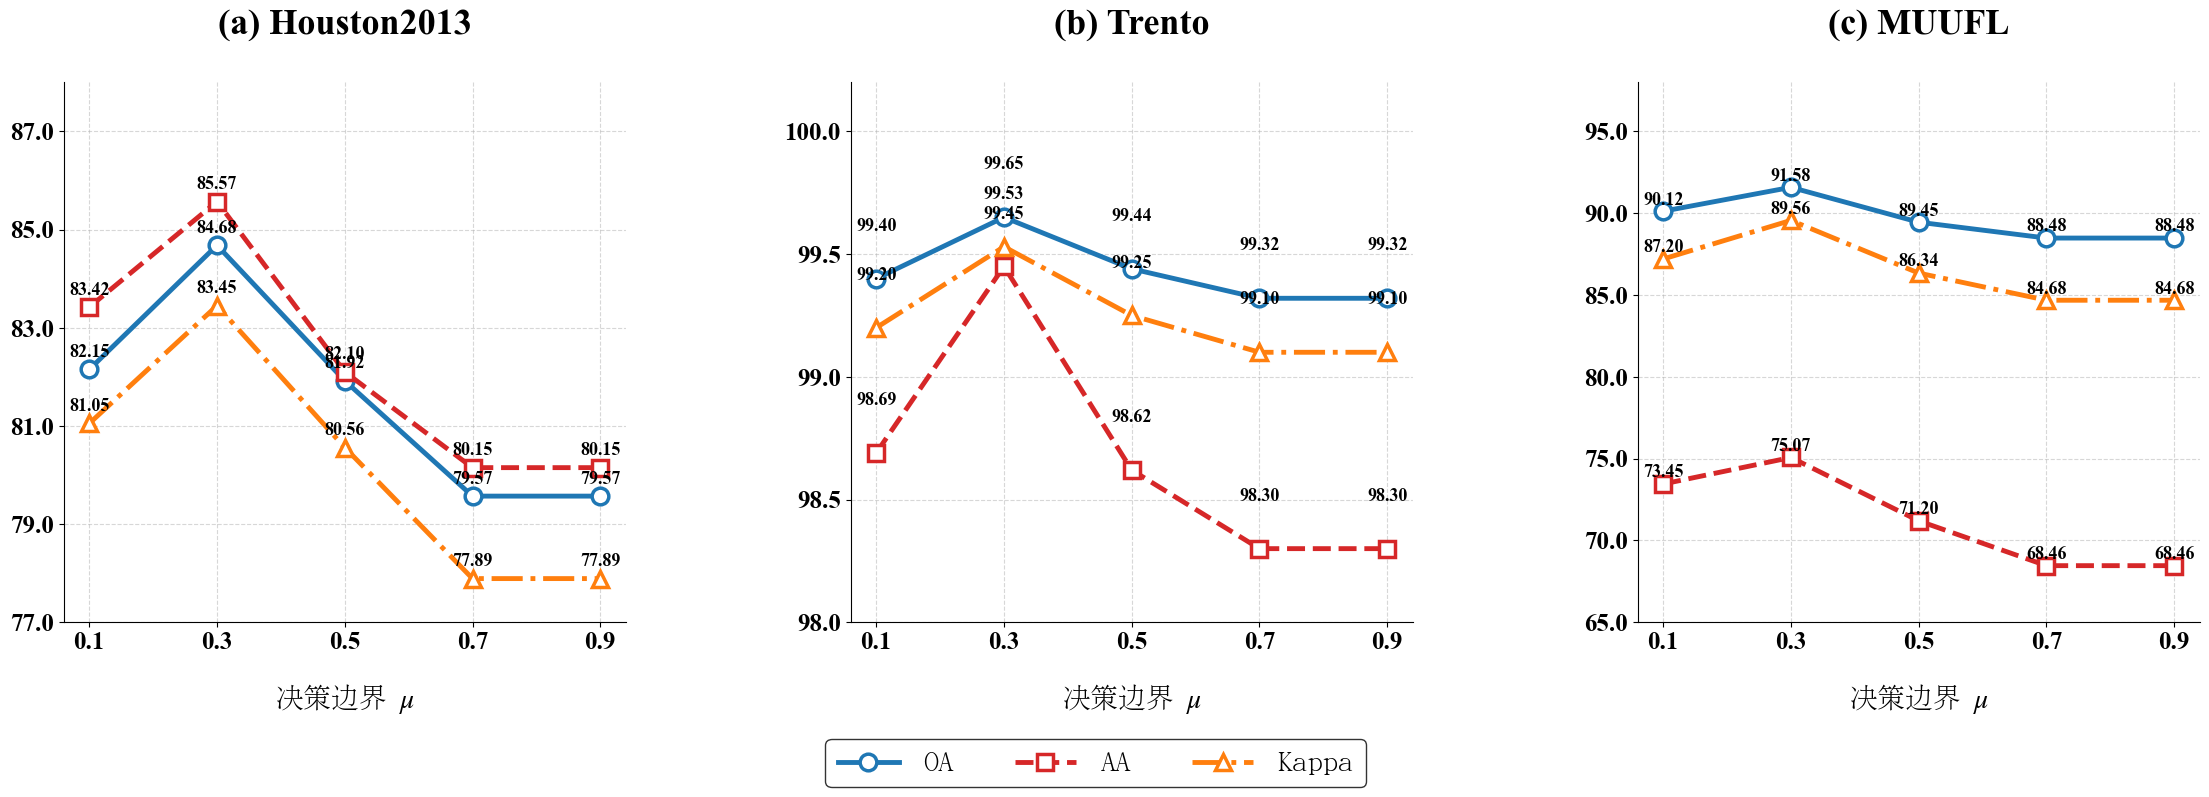

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
from matplotlib.ticker import FormatStrFormatter

# ========= 1. 字体全局配置 =========
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['mathtext.fontset'] = 'stix'
rcParams['axes.unicode_minus'] = False

# 中文字体路径
font_path = "/usr/share/fonts/truetype/arphic/uming.ttc" 
cn_font_label = font_manager.FontProperties(fname=font_path, size=20, weight='bold')
cn_font_legend = font_manager.FontProperties(fname=font_path, size=22, weight='bold')

# ========= 2. 数据 =========
mu_values = ["0.1", "0.3", "0.5", "0.7", "0.9"]
metrics = ["OA", "AA", "Kappa"]

trento_data = np.array([[99.40, 98.69, 99.20], [99.65, 99.45, 99.53], [99.44, 98.62, 99.25], [99.32, 98.30, 99.10], [99.32, 98.30, 99.10]])
houston_data = np.array([[82.15, 83.42, 81.05], [84.68, 85.57, 83.45], [81.92, 82.10, 80.56], [79.57, 80.15, 77.89], [79.57, 80.15, 77.89]])
muufl_data = np.array([[90.12, 73.45, 87.20], [91.58, 75.07, 89.56], [89.45, 71.20, 86.34], [88.48, 68.46, 84.68], [88.48, 68.46, 84.68]])

datasets = [("Houston2013", houston_data), ("Trento", trento_data), ("MUUFL", muufl_data)]

# ========= 3. 绘图核心逻辑 =========
fig, axes = plt.subplots(1, 3, figsize=(24, 9)) # 进一步加大画布

colors = ['#1F77B4', '#D62728', '#FF7F0E']
markers = ['o', 's', '^']
linestyles = ['-', '--', '-.']

for i, (name, data) in enumerate(datasets):
    ax = axes[i]
    for j in range(len(metrics)):
        # 绘制折线
        ax.plot(mu_values, data[:, j], label=metrics[j],
                color=colors[j], marker=markers[j], linestyle=linestyles[j],
                linewidth=3.5, markersize=12, markerfacecolor='white', markeredgewidth=2.5)
        
        # --- 数值标注：字号加大 ---
        for x_idx, y_val in enumerate(data[:, j]):
            ax.text(x_idx, y_val + 0.18, 
                    f'{y_val:.2f}',
                    ha='center', va='bottom',
                    fontdict={'family': 'Times New Roman', 'size': 13, 'weight': 'bold'},
                    clip_on=False)
    
    # 标题
    ax.set_title(f"({chr(97+i)}) {name}", pad=35, 
                 fontdict={'family': 'Times New Roman', 'size': 26, 'weight': 'bold'})
    
    # X轴标签
    ax.set_xlabel(r'决策边界 $\mu$', fontproperties=cn_font_label, labelpad=20)
    
    # X轴刻度
    ax.set_xticks(range(len(mu_values)))
    ax.set_xticklabels(mu_values, fontdict={'family': 'Times New Roman', 'size': 18, 'weight': 'bold'})
    
    # --- Y轴设置：带小数刻度 & 增加区分度 ---
    if name == "Trento":
        ymin, ymax = 98.0, 100.0  # 缩小量程以增大 Trento 的起伏感
        ticks = np.arange(98.0, 100.1, 0.5)
    elif name == "MUUFL":
        ymin, ymax = 65.0, 95.0   # 优化 MUUFL 量程
        ticks = np.arange(65.0, 95.1, 5.0)
    else: # Houston2013
        ymin, ymax = 77.0, 87.0   # 优化 Houston 量程
        ticks = np.arange(77.0, 87.1, 2.0)
        
    ax.set_ylim(ymin, ymax + (ymax-ymin)*0.1) # 顶部留出 10% 空间给数值标注
    ax.set_yticks(ticks)
    
    # 设置刻度为一位小数
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
    # Y轴刻度字体
    for tick in ax.get_yticklabels():
        tick.set_fontname('Times New Roman')
        tick.set_fontsize(18)
        tick.set_weight('bold')
    
    # --- 移除上方和右方的线 ---
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 增强网格视觉效果
    ax.grid(True, which='major', linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

# ========= 4. 图例与布局 =========
handles, labels_legend = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_legend, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=3, 
           frameon=True, edgecolor='black', prop=cn_font_legend)

# wspace 再次拉开，确保左侧子图的标注不撞到右侧子图的坐标轴
plt.subplots_adjust(bottom=0.22, wspace=0.4, top=0.82, left=0.07, right=0.96)

plt.savefig("decision_boundary_float_ticks.png", dpi=300, bbox_inches='tight')
plt.show()

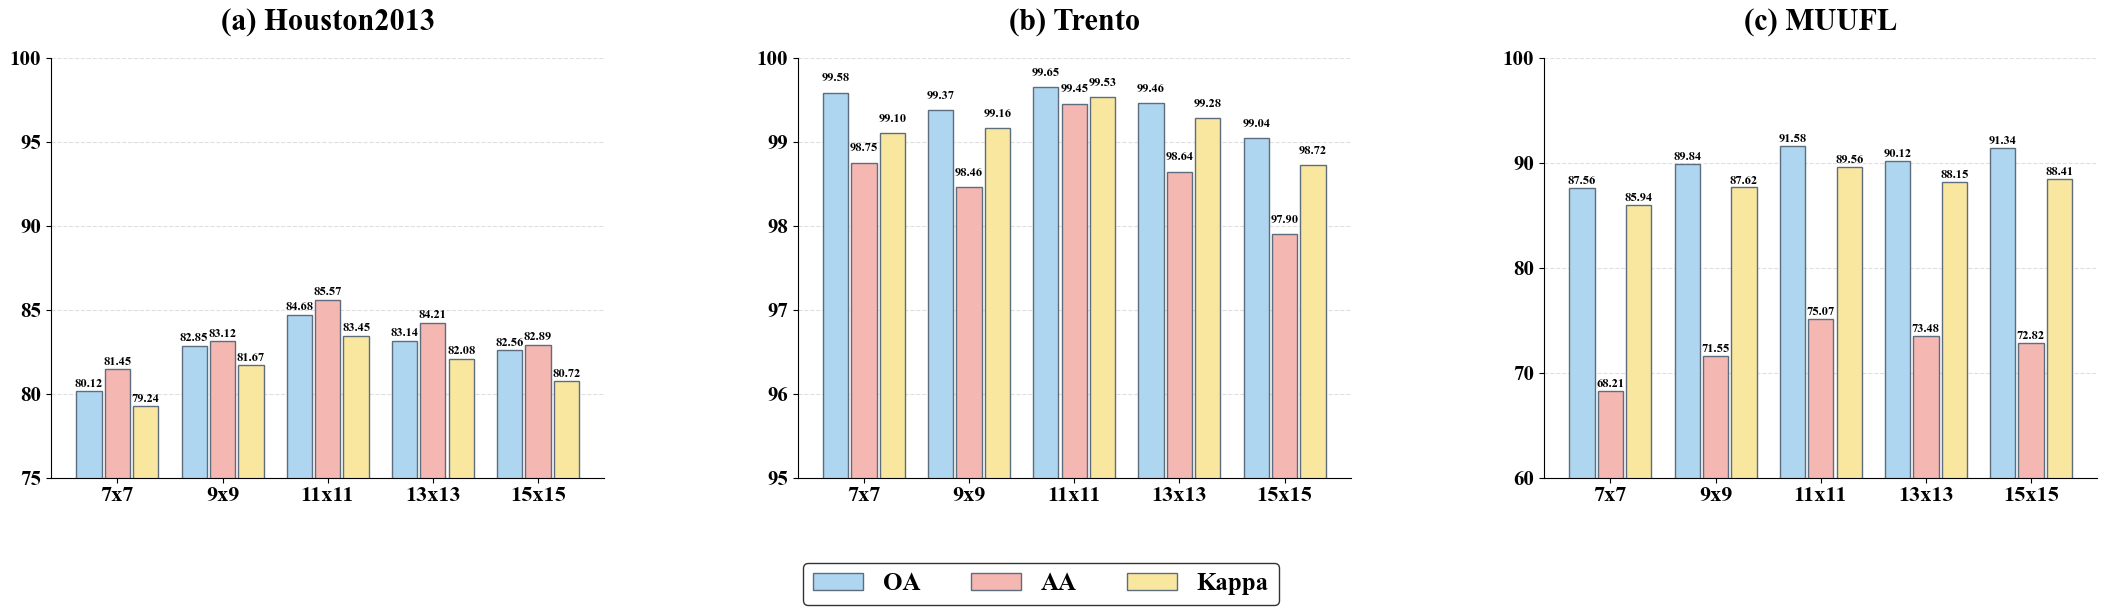

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

# ========= 1. 字体全局配置 =========
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['mathtext.fontset'] = 'stix'
rcParams['axes.unicode_minus'] = False

# 中文字体路径 (请确保路径正确)
font_path = "/usr/share/fonts/truetype/arphic/uming.ttc" 
cn_font_legend = font_manager.FontProperties(fname=font_path, size=18, weight='bold')

# ========= 2. 实验数据 =========
patch_sizes = ["7x7", "9x9", "11x11", "13x13", "15x15"]
metrics = ["OA", "AA", "Kappa"]

houston_data = np.array([
    [80.12, 81.45, 79.24],
    [82.85, 83.12, 81.67],
    [84.68, 85.57, 83.45],
    [83.14, 84.21, 82.08],
    [82.56, 82.89, 80.72]
])

trento_data = np.array([
    [99.58, 98.75, 99.10],
    [99.37, 98.46, 99.16],
    [99.65, 99.45, 99.53],
    [99.46, 98.64, 99.28],
    [99.04, 97.90, 98.72]
])

muufl_data = np.array([
    [87.56, 68.21, 85.94],
    [89.84, 71.55, 87.62],
    [91.58, 75.07, 89.56],
    [90.12, 73.48, 88.15],
    [91.34, 72.82, 88.41]
])

datasets = [
    ("Houston2013", houston_data),
    ("Trento", trento_data),
    ("MUUFL", muufl_data)
]

# ========= 3. 绘图核心逻辑 =========
# 增加 figsize 宽度，给数值更多横向空间
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

colors = ['#AED6F1', '#F5B7B1', '#F9E79F'] 
x = np.arange(len(patch_sizes))

# --- 关键调整：柱子宽度与间距 ---
width = 0.24      # 柱子本身宽度
inner_gap = 0.03  # 同一组内柱子之间的微小空隙
# ----------------------------

for i, (name, data) in enumerate(datasets):
    ax = axes[i]
    
    # 绘制分组柱状图
    for j in range(len(metrics)):
        # 计算每个柱子的中心位置，确保它们之间有 inner_gap
        pos = x + (j - 1) * (width + inner_gap)
        rects = ax.bar(pos, data[:, j], width, label=metrics[j],
                       color=colors[j], edgecolor='#5D6D7E', linewidth=1.0)
        
        # --- 数值标注：保留两位小数 ---
        for rect in rects:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width()/2., height + 0.1,
                    f'{height:.2f}', 
                    ha='center', va='bottom', 
                    fontdict={'family': 'Times New Roman', 'size': 9, 'weight': 'bold'},
                    clip_on=False)
    
    # --- 标题设计 ---
    ax.text(0.5, 1.08, f"({chr(97+i)}) {name}", 
            transform=ax.transAxes, ha='center', va='center',
            fontdict={'family': 'Times New Roman', 'size': 22, 'weight': 'bold'})
    
    # --- X轴设置 ---
    ax.set_xticks(x)
    ax.set_xticklabels(patch_sizes, fontdict={'family': 'Times New Roman', 'size': 16, 'weight': 'bold'})
    
    # --- Y轴设置 ---
    if name == "Trento":
        ymin, ymax = 95, 100
        ticks = [95, 96, 97, 98, 99, 100]
    elif name == "MUUFL":
        ymin, ymax = 60, 100
        ticks = [60, 70, 80, 90, 100]
    else: 
        ymin, ymax = 75, 100
        ticks = [75, 80, 85, 90, 95, 100]
        
    ax.set_ylim(ymin, ymax)
    ax.set_yticks(ticks)
    ax.set_yticklabels([str(int(t)) for t in ticks], 
                        fontdict={'family': 'Times New Roman', 'size': 15, 'weight': 'bold'})
    
    # --- 去掉上方和右方的线 ---
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 网格线
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)

# ========= 4. 图例与布局优化 =========
handles, labels_legend = axes[0].get_legend_handles_labels()

fig.legend(handles, labels_legend, 
            loc='lower center', 
            bbox_to_anchor=(0.5, 0.05),
            ncol=3, 
            frameon=True,
            edgecolor='black',
            prop={'family': 'Times New Roman', 'size': 18, 'weight': 'bold'})

# wspace 增加子图间距，确保数值不重叠
plt.subplots_adjust(bottom=0.25, wspace=0.35, top=0.85, left=0.05, right=0.98)

plt.savefig("patch_size_sensitivity_refined.png", dpi=300, bbox_inches='tight')
plt.show()

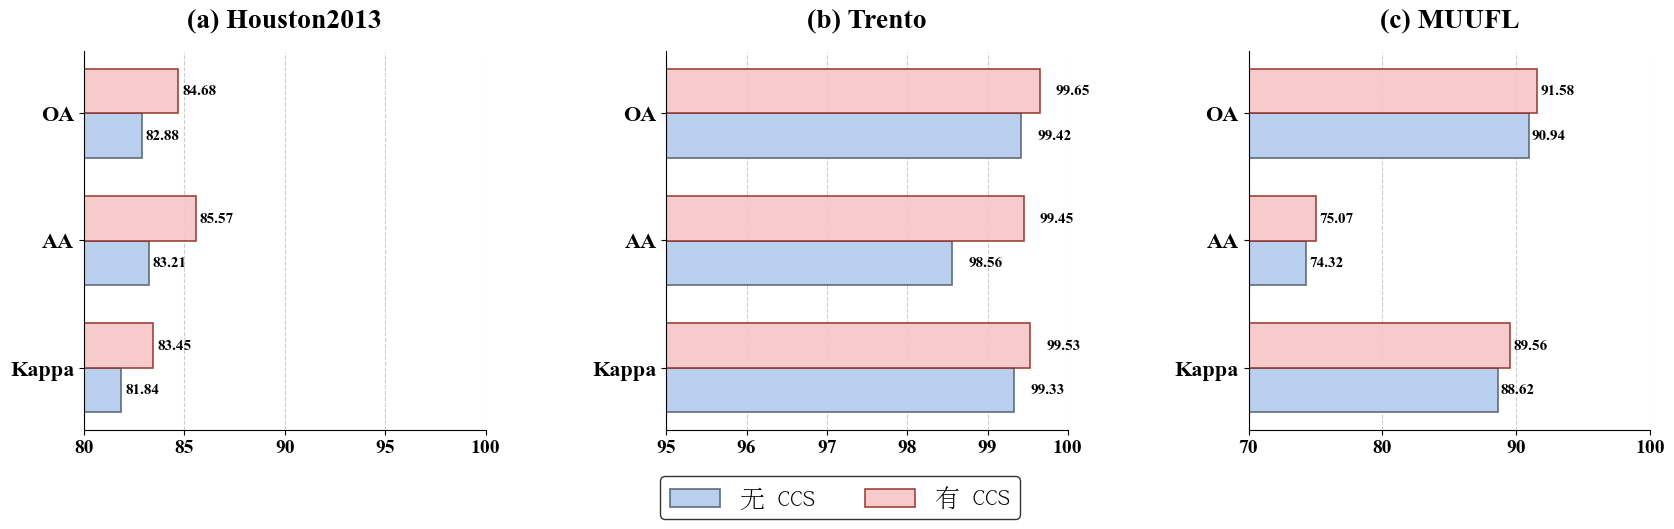

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

# ========= 1. 字体全局配置 =========
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['mathtext.fontset'] = 'stix'
rcParams['axes.unicode_minus'] = False

# 中文字体路径 (请确保路径正确)
font_path = "/usr/share/fonts/truetype/arphic/uming.ttc" 
cn_font_legend = font_manager.FontProperties(fname=font_path, size=18, weight='bold')

# ========= 2. 数据更新 (CCS 模块) =========
datasets = ["Houston2013", "Trento", "MUUFL"]
metrics = ['OA', 'AA', 'Kappa'][::-1] 

with_ccs = {
    "Houston2013": [84.68, 85.57, 83.45][::-1],
    "Trento":      [99.65, 99.45, 99.53][::-1],
    "MUUFL":       [91.58, 75.07, 89.56][::-1]
}

without_ccs = {
    "Houston2013": [82.88, 83.21, 81.84][::-1],
    "Trento":      [99.42, 98.56, 99.33][::-1],
    "MUUFL":       [90.94, 74.32, 88.62][::-1]
}

# ========= 3. 绘图 =========
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # 稍微加宽整体画布

color_no = '#B9CFED'   
color_with = '#F7C6C7' 
y = np.arange(len(metrics))
height = 0.35 

for i, name in enumerate(datasets):
    ax = axes[i]
    
    data_no = without_ccs[name]
    data_with = with_ccs[name]
    
    # 绘制横向柱状图
    rects1 = ax.barh(y - height/2, data_no, height, label='无 CCS', 
                     color=color_no, edgecolor='#5D6D7E', linewidth=1.2)
    rects2 = ax.barh(y + height/2, data_with, height, label='有 CCS', 
                     color=color_with, edgecolor='#943126', linewidth=1.2, alpha=0.9)
    
    # --- 数值标注：始终在外部 ---
    def autolabel(rects):
        for rect in rects:
            width = rect.get_width()
            # clip_on=False 保证文字超出坐标轴范围时依然可见
            ax.text(width + 0.2, rect.get_y() + rect.get_height()/2.,
                    f'{width:.2f}',
                    ha='left', va='center',
                    fontdict={'family': 'Times New Roman', 'size': 11, 'weight': 'bold'},
                    clip_on=False) 

    autolabel(rects1)
    autolabel(rects2)
    
    # --- 标题 ---
    ax.text(0.5, 1.08, f"({chr(97+i)}) {name}", 
            transform=ax.transAxes, ha='center', va='center',
            fontdict={'family': 'Times New Roman', 'size': 20, 'weight': 'bold'})
    
    # --- Y轴设置 ---
    ax.set_yticks(y)
    ax.set_yticklabels(metrics, fontdict={'family': 'Times New Roman', 'size': 16, 'weight': 'bold'})
    
    # --- X轴设置 ---
    if name == "Trento":
        xmin, xmax = 95, 100
        ticks = [95, 96, 97, 98, 99, 100]
    elif name == "MUUFL":
        xmin, xmax = 70, 100
        ticks = [70, 80, 90, 100]
    else: 
        xmin, xmax = 80, 100
        ticks = [80, 85, 90, 95, 100]

    ax.set_xlim(xmin, xmax) 
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(int(t)) for t in ticks], 
                        fontdict={'family': 'Times New Roman', 'size': 14, 'weight': 'bold'})
    
    # --- 去掉上方和右方的线 ---
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.grid(axis='x', linestyle='--', alpha=0.4, color='gray')
    ax.set_axisbelow(True)

# ========= 4. 布局与图例 =========
handles, labels_legend = axes[0].get_legend_handles_labels()

fig.legend(handles, labels_legend, 
            loc='lower center', 
            bbox_to_anchor=(0.5, 0.05),
            ncol=2, 
            frameon=True,
            edgecolor='black',
            prop=cn_font_legend)

# wspace 增加子图间距，left 增加左边留白，right 缩小右边留白给数值腾位置
plt.subplots_adjust(bottom=0.22, wspace=0.45, top=0.85, left=0.08, right=0.95)

plt.savefig("ccs_ablation_final_no_clip.png", dpi=300, bbox_inches='tight')
plt.show()

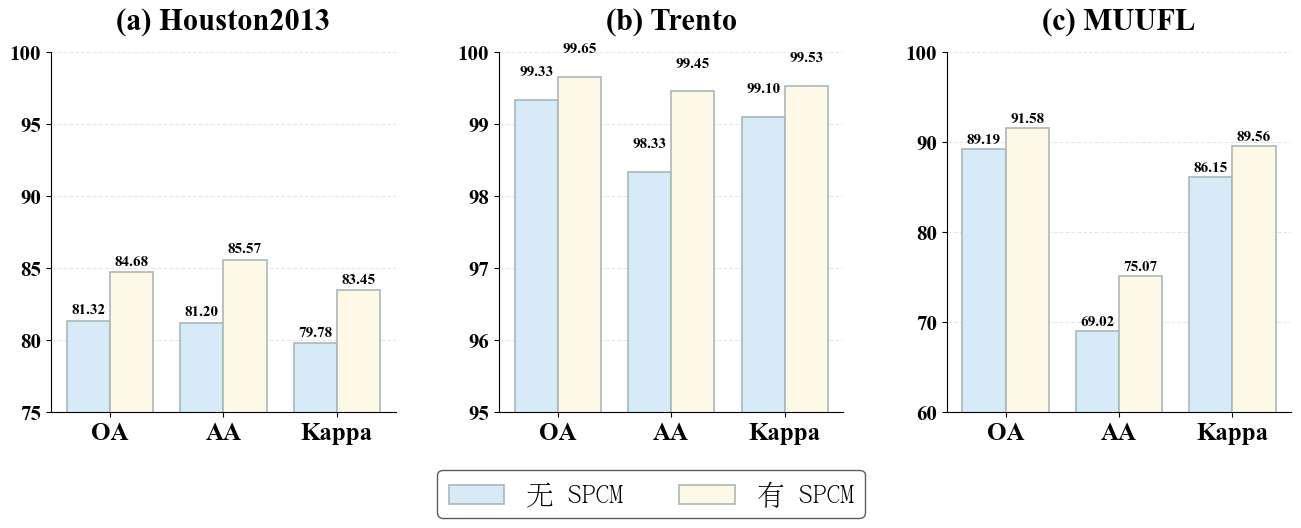

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

# ========= 1. 字体全局配置 =========
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['mathtext.fontset'] = 'stix'
rcParams['axes.unicode_minus'] = False

# 中文字体路径 (根据实际系统路径修改)
font_path = "/usr/share/fonts/truetype/arphic/uming.ttc" 
cn_font_legend = font_manager.FontProperties(fname=font_path, size=20, weight='bold')

# ========= 2. 数据 =========
datasets = ["Houston2013", "Trento", "MUUFL"]
metrics = ['OA', 'AA', 'Kappa']

with_spcm = {
    "Houston2013": [84.68, 85.57, 83.45],
    "Trento":      [99.65, 99.45, 99.53],
    "MUUFL":       [91.58, 75.07, 89.56]
}

without_spcm = {
    "Houston2013": [81.32, 81.20, 79.78],
    "Trento":      [99.33, 98.33, 99.10],
    "MUUFL":       [89.19, 69.02, 86.15]
}

# ========= 3. 绘图 =========
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

color_no = '#D6EAF8'   # 极浅蓝灰色
color_with = '#FEF9E7' # 极浅淡黄色
x = np.arange(len(metrics))
width = 0.38

for i, name in enumerate(datasets):
    ax = axes[i]
    
    data_no = without_spcm[name]
    data_with = with_spcm[name]
    
    # 绘制柱状图
    rects1 = ax.bar(x - width/2, data_no, width, label='无 SPCM', 
                    color=color_no, edgecolor='#AAB7B8', linewidth=1.2)
    rects2 = ax.bar(x + width/2, data_with, width, label='有 SPCM', 
                    color=color_with, edgecolor='#AAB7B8', linewidth=1.2)
    
    # --- 数值标注 ---
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            # 统一标注在柱子上方，由于去掉了顶线，不会产生压迫感
            ax.text(rect.get_x() + rect.get_width()/2., height + 0.3,
                    f'{height:.2f}',
                    ha='center', va='bottom',
                    fontdict={'family': 'Times New Roman', 'size': 11, 'weight': 'bold'})

    autolabel(rects1)
    autolabel(rects2)
    
    # --- 标题 ---
    ax.text(0.5, 1.08, f"({chr(97+i)}) {name}", 
            transform=ax.transAxes, ha='center', va='center',
            fontdict={'family': 'Times New Roman', 'size': 22, 'weight': 'bold'})
    
    # --- X轴设置 ---
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontdict={'family': 'Times New Roman', 'size': 18, 'weight': 'bold'})
    
    # --- Y轴范围控制 ---
    if name == "Trento":
        lower_limit, ticks = 95, [95, 96, 97, 98, 99, 100]
    elif name == "MUUFL":
        lower_limit, ticks = 60, [60, 70, 80, 90, 100]
    else:
        lower_limit, ticks = 75, [75, 80, 85, 90, 95, 100]

    ax.set_ylim(lower_limit, 100)
    ax.set_yticks(ticks)
    ax.set_yticklabels([str(int(t)) for t in ticks], 
                        fontdict={'family': 'Times New Roman', 'size': 15, 'weight': 'bold'})
    
    # --- 重点：去掉上方和右方的边框线 ---
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)

# ========= 4. 布局与图例 =========
handles, labels_legend = axes[0].get_legend_handles_labels()

fig.legend(handles, labels_legend, 
            loc='lower center', 
            bbox_to_anchor=(0.5, 0.05),
            ncol=2, 
            frameon=True,
            edgecolor='#333333',
            prop=cn_font_legend)

plt.subplots_adjust(bottom=0.25, wspace=0.3, top=0.85)

plt.savefig("spcm_ablation_final_clean.png", dpi=300, bbox_inches='tight')
plt.show()